# Task 3b: Held-Out TDK Evaluation

This notebook evaluates the single checkpoint selected using **non-TDK validation WER** in Task 3a. It does not tune parameters on TDK. The baseline `generated_text` is preserved, and `generated_text_ft` is added. Python helpers implement resumable inference; this notebook records the experiment and comparison.

Default mode replays the recorded full-corpus result on CPU. Set RUN_TDK_INFERENCE=1, YCSEP_MODEL and TDK_CACHE explicitly to run new inference. The model was selected using non-TDK validation only.

In [1]:
import os, sys, json
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'asr-train':
    ROOT = ROOT.parent
sys.path[:0] = [str(ROOT / 'asr-train'), str(ROOT / 'asr')]
BASE = Path(os.environ.get('TDK_BASE', ROOT / 'asr/TDK_subset.csv'))
MODEL = Path(os.environ.get('YCSEP_MODEL', ROOT / 'asr-train/models/parakeet-tdt-0.6b-v3-ycsep.nemo'))
OUTPUT = Path(os.environ.get('TDK_EVALUATION', ROOT / 'test_docs/test/runtime/final-tdk-evaluation'))
CACHE = os.environ.get('TDK_CACHE') or None

rerun = os.environ.get('RUN_TDK_INFERENCE') == '1'
OUTPUT.mkdir(parents=True, exist_ok=True)

## Audio and Reproducibility
Prefer the verified MP3 caches from Task 2c so the two models see identical audio. If unavailable, the helper extracts the original YCSEP WAV timestamp range and encodes MP3 using the same fallback as Task 2c. This is not byte-identical to the CSV's original MP3; report which path was used. Both paths use librosa mono 16 kHz loading followed by PCM WAV, matching the API preprocessing. The checkpoint and baseline CSV hashes bind the resume journal.

Before the final run, confirm that the baseline has **all 218,011 TDK rows** and zero API errors. Empty successful transcriptions are valid model outputs, not missing rows.

In [2]:
import csv
with BASE.open(encoding='utf-8-sig', newline='') as handle:
    baseline_rows = list(csv.DictReader(handle))
assert len(baseline_rows) == 218011, 'Final TDK baseline is incomplete'
assert all(r['channel'] == 'The_Daily_Ketchup_Podcast' and not r['asr_error'] for r in baseline_rows)
if rerun:
    assert MODEL.is_file(), 'Selected Task 3a model is required'
print({'baseline_rows': len(baseline_rows), 'checkpoint': MODEL.name})


{'baseline_rows': 218011, 'checkpoint': 'parakeet-tdt-0.6b-v3-ycsep.nemo'}


In [3]:
if rerun:
    from evaluate_tdk import evaluate
    result = evaluate(BASE, MODEL, OUTPUT, batch_size=8, workers=8, cache=CACHE)
    raw = OUTPUT / 'TDK_subset_ft.csv'
else:
    assert all('generated_text_ft' in r and not r['asr_error_ft'] for r in baseline_rows)
    result = json.loads((ROOT / 'asr-train/results/E1-TDK/evaluation-provenance.json').read_text())
    raw = BASE
    print('Replaying recorded full-corpus predictions; no GPU inference.')
result

Replaying recorded full-corpus predictions; no GPU inference.


{'rows': 218011,
 'failed': 0,
 'model_sha256': '8860f2759272a5585b7d8034492a15c2ee10ca68ff3db75698dea5a36e903e2d',
 'shards': [{'index': 0,
   'rows': 27252,
   'csv_sha256': '345bab09989d490afef943dc6a816725ca85031b6f8a512afab296fc0c879b17'},
  {'index': 1,
   'rows': 27252,
   'csv_sha256': '071e9e99e045eda5baa892abeb93dd0c2c4141022d83c4be9c8268b01970cc2e'},
  {'index': 2,
   'rows': 27252,
   'csv_sha256': '257f5b87fadf6dfa0d23ce6b02e95bb9bff5040fe15a18e58ac2079a913e7f1c'},
  {'index': 3,
   'rows': 27251,
   'csv_sha256': '5927992f635865148a97e3c99d59f989a219c6ef0080138c056c5d9edcb94d20'},
  {'index': 4,
   'rows': 27251,
   'csv_sha256': '95ab2cd29284d04470e7c8191eacc6769a225c310f0a8a62fc6bb960f8ab8f95'},
  {'index': 5,
   'rows': 27251,
   'csv_sha256': '7efbdbec7f729f32287cdd6ee82a888e28d864c2727b14d9cc0000dd27cea28a'},
  {'index': 6,
   'rows': 27251,
   'csv_sha256': 'ad4b0cfac31d782dd144346688917476f76fecdd1ef7da82ddf7d3f05fe89daa'},
  {'index': 7,
   'rows': 27251,
   'csv_

## Paired Metrics
WER is the primary metric, calculated as pooled substitutions + deletions + insertions divided by total reference words, not the mean of row WER. CER is secondary. The same Unicode NFKC/case-fold/word normalization is applied to both systems; CER excludes spaces. Empty-reference rows retain insertion counts in the pooled numerator. Failed inference must be resolved before declaring final performance.

In [4]:
from score_transcriptions import score
base_metrics = score(raw, OUTPUT / 'TDK_base_scored.csv')
ft_metrics = score(OUTPUT / 'TDK_base_scored.csv', OUTPUT / 'TDK_subset.csv',
                   prediction='generated_text_ft', suffix='ft', error_column='asr_error_ft')
assert base_metrics['coverage'] == ft_metrics['coverage'] == 1
comparison = {'base_wer': base_metrics['corpus_wer'], 'ft_wer': ft_metrics['corpus_wer'],
              'base_cer': base_metrics['corpus_cer'], 'ft_cer': ft_metrics['corpus_cer']}
comparison['absolute_wer_change'] = comparison['ft_wer'] - comparison['base_wer']
comparison['relative_wer_reduction'] = (1-comparison['ft_wer']/comparison['base_wer']) if comparison['base_wer'] else None
(OUTPUT / 'comparison.json').write_text(json.dumps(comparison, indent=2), encoding='utf-8')
from compare_models import compare
paired = compare(OUTPUT / 'TDK_subset.csv', OUTPUT)
assert abs(paired['base_wer'] - comparison['base_wer']) < 1e-12
assert abs(paired['ft_wer'] - comparison['ft_wer']) < 1e-12
paired


{
  "rows": 218011,
  "scored": 218011,
  "failed": 0,
  "word_edits": 607513,
  "reference_words": 2487035,
  "character_edits": 1831500,
  "reference_characters": 10103081,
  "empty_references": 0,
  "corpus_wer": 0.2442719945638079,
  "corpus_cer": 0.1812813338822088,
  "coverage": 1.0,
  "normalization": "unicode_nfkc_casefold_words_apostrophes_v1; CER excludes spaces",
  "prediction_column": "generated_text",
  "source_sha256": "941858227a7d15f115b81c2542dfedee8b67ca7de1385665470869ab5917e6d0"
}


{
  "rows": 218011,
  "scored": 218011,
  "failed": 0,
  "word_edits": 530036,
  "reference_words": 2487035,
  "character_edits": 1600016,
  "reference_characters": 10103081,
  "empty_references": 0,
  "corpus_wer": 0.21311963844497564,
  "corpus_cer": 0.15836911532234574,
  "coverage": 1.0,
  "normalization": "unicode_nfkc_casefold_words_apostrophes_v1; CER excludes spaces",
  "prediction_column": "generated_text_ft",
  "source_sha256": "941858227a7d15f115b81c2542dfedee8b67ca7de1385665470869ab5917e6d0"
}


{'scope': 'full_tdk',
 'rows': 218011,
 'videos': 367,
 'failed_rows': 0,
 'base_wer': 0.2442719945638079,
 'ft_wer': 0.21311963844497564,
 'base_cer': 0.1812813338822088,
 'ft_cer': 0.15836911532234574,
 'delta_wer': -0.031152356118832263,
 'relative_wer_reduction': 0.12753142731102052,
 'delta_wer_95pct_video_bootstrap': [-0.03227337364186119,
  -0.030055305335050415],
 'valid_bootstrap_draws': 2000,
 'bootstrap_samples': 2000,
 'seed': 2026,
 'normalization': 'unicode_nfkc_casefold_words_apostrophes_v1; CER excludes spaces',
 'bootstrap_assumption': 'Videos treated as independent clusters; recurring speakers can violate this assumption'}

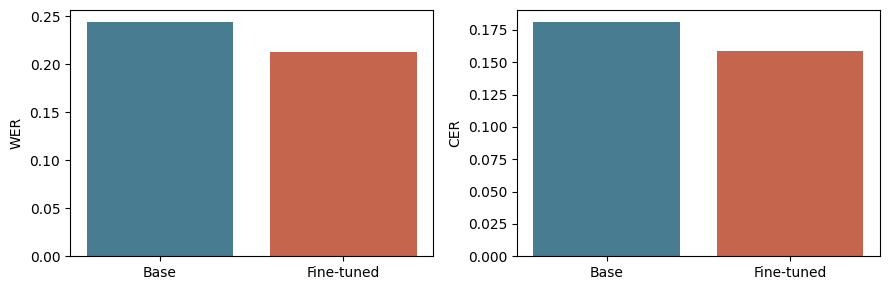

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, metric in zip(axes, ('wer', 'cer')):
    ax.bar(['Base', 'Fine-tuned'], [comparison['base_'+metric], comparison['ft_'+metric]], color=['#477c91', '#c4654e'])
    ax.set_ylabel(metric.upper())
    ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()


In [6]:
from analyze_errors import analyze
analyze(OUTPUT / 'TDK_subset.csv', OUTPUT)


{'interpretation': 'Post-test descriptive slices, not tuning criteria. Short segments and reference alignment may confound results.',
 'row_outcomes': {'regressed': 36169, 'unchanged': 116215, 'improved': 65627},
 'video_outcomes': {'improved': 355, 'regressed': 12},
 'slices': {'all': {'rows': 218011,
   'words': 2487035,
   'base_edits': 607513,
   'ft_edits': 530036,
   'base_wer': 0.2442719945638079,
   'ft_wer': 0.21311963844497564},
  'duration:2-5s': {'rows': 62338,
   'words': 790503,
   'base_edits': 192069,
   'ft_edits': 169808,
   'base_wer': 0.24297061491227737,
   'ft_wer': 0.21481006397192673},
  'duration:5-10s': {'rows': 29134,
   'words': 780489,
   'base_edits': 132329,
   'ft_edits': 115750,
   'base_wer': 0.16954627163227157,
   'ft_wer': 0.148304460408795},
  'duration:<2s': {'rows': 117758,
   'words': 437040,
   'base_edits': 217684,
   'ft_edits': 188589,
   'base_wer': 0.49808713161266704,
   'ft_wer': 0.4315142778693026},
  'duration:>=10s': {'rows': 8781,
  

## Observed Full-TDK Results
All 218,011 rows across 367 videos have successful paired predictions. Corpus WER decreases from **24.4272% to 21.3120%**: a **3.1152 percentage-point** reduction, or **12.7531% relative**. CER decreases from **18.1281% to 15.8369%**. Word errors fall from 607,513 to 530,036 over 2,487,035 reference words.

The 2,000-draw source-video cluster bootstrap gives a 95% interval of **[-3.2273, -3.0055] percentage points** for FT-minus-base WER (seed 2026). This supports an improvement within this corpus under the assumption that videos are independent clusters. Recurring speakers and related episodes may violate that assumption; this is not an uncertainty interval for all Singapore English.

355 videos improve and 12 regress. At row level, 65,627 improve, 36,169 regress and 116,215 tie in word-edit count. Pooled WER improves in each duration band; clips shorter than two seconds remain difficult (49.81% to 43.15%), compared with 13.66% to 11.67% for clips at least ten seconds long. Fragmentation, overlap and reference alignment are plausible explanations, not verified causes.

Error examples include better acronym formatting ("PIE, ECP, KPE") and reduced repetitions, but repetition and missing words remain in some FT outputs. The saved largest-change examples are intentionally diagnostic, not representative samples. No listening-based causal labels or calibrated code-switching subgroup claims are made.

E1 was frozen using non-TDK validation before this test. These TDK observations support the Task 4 report, not another round of checkpoint selection. The separate E2 data-expansion experiment is not included in these results. No denoising, UTMOS/SIGMOS filtering or tokenizer replacement was performed.
